# 04 - Reducción de dimensionalidad con PCA

En este notebook se aplica Análisis de Componentes Principales (PCA) sobre las variables numéricas del dataset limpio.

El objetivo es analizar si es posible representar la información principal del dataset en menos dimensiones, observando la varianza explicada por cada componente y la contribución de las variables originales.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/PI_Mineria_Datos_1/notebooks

/content/drive/MyDrive/PI_Mineria_Datos_1/notebooks


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv(
    "../data/processed/streaming_users_clean.csv",
    parse_dates=["last_login_date"]
)

df.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crimen,2025-03-04,1
1,10001,37,Estándar,1173.4,Colombia,Crimen,2019-04-02,2
2,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   8000 non-null   int64         
 1   age                       8000 non-null   int64         
 2   subscription_plan         8000 non-null   object        
 3   monthly_watch_time_mins   8000 non-null   float64       
 4   country                   8000 non-null   object        
 5   favorite_genre            7763 non-null   object        
 6   last_login_date           7606 non-null   datetime64[ns]
 7   customer_support_tickets  8000 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 500.1+ KB


El PCA se aplicará únicamente sobre variables numéricas, ya que esta técnica trabaja con datos cuantitativos.

Además, antes de aplicar PCA es necesario escalar las variables, porque si las variables tienen rangos diferentes, aquellas con valores más grandes pueden dominar artificialmente el resultado.

In [6]:
# Seleccionamos variables numéricas relevantes para PCA

variables_pca = [
    "age",
    "monthly_watch_time_mins",
    "customer_support_tickets"
]

X = df[variables_pca]

X.head()

,age,monthly_watch_time_mins,customer_support_tickets
0,39,805.8,1
1,37,1173.4,2
2,28,401.0,0
3,43,62.4,0
4,51,477.8,1


Para aplicar PCA se seleccionan variables numéricas relevantes del dataset: edad, tiempo mensual de visualización y cantidad de tickets de soporte.

No se incluye `user_id`, ya que es un identificador y no representa una característica cuantitativa del comportamiento del usuario.

In [7]:
# Verificamos si las variables seleccionadas tienen valores nulos

X.isnull().sum()

,0
age,0
monthly_watch_time_mins,0
customer_support_tickets,0


Antes de aplicar PCA se verifica que las variables seleccionadas no contengan valores nulos, ya que PCA no puede trabajar directamente con valores faltantes.

In [8]:
# Escalamos las variables numéricas antes de aplicar PCA

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [9]:
# Convertimos el resultado escalado a DataFrame para visualizarlo mejor

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=variables_pca
)

X_scaled_df.head()

,age,monthly_watch_time_mins,customer_support_tickets
0,0.465211,0.025419,0.220528
1,0.292202,0.779295,1.339250
2,-0.486339,-0.804747,-0.898194
3,0.811229,-1.499150,-0.898194
4,1.503265,-0.647245,0.220528


Se aplica `StandardScaler` para estandarizar las variables numéricas antes de PCA.

Esto transforma las variables para que tengan media cercana a 0 y desviación estándar cercana a 1.  
De esta manera, ninguna variable domina el análisis solo por tener valores numéricos más grandes.

In [10]:
# Verificamos media y desvío estándar después del escalamiento

resumen_escalado = pd.DataFrame({
    "Media": X_scaled_df.mean().round(2),
    "Desvío estándar": X_scaled_df.std().round(2)
})

resumen_escalado

,Media,Desvío estándar
age,0.0,1.0
monthly_watch_time_mins,0.0,1.0
customer_support_tickets,-0.0,1.0


In [11]:
# Aplicamos PCA usando todas las componentes posibles

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [12]:
# Calculamos la varianza explicada por cada componente

varianza_explicada = pca.explained_variance_ratio_

varianza_pca = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(varianza_explicada))],
    "Varianza explicada (%)": (varianza_explicada * 100).round(2),
    "Varianza acumulada (%)": (varianza_explicada.cumsum() * 100).round(2)
})

varianza_pca

,Componente,Varianza explicada (%),Varianza acumulada (%)
0,PC1,33.59,33.59
1,PC2,33.41,67.00
2,PC3,33.00,100.00


### Interpretación de la varianza explicada

La tabla muestra que las tres componentes principales explican porcentajes muy similares de la varianza total.

PC1 explica aproximadamente el 33.59%, PC2 el 33.41% y PC3 el 33.00%. Esto indica que no hay una única componente que concentre la mayor parte de la información.

Al usar solo PC1 y PC2 se conserva aproximadamente el 67% de la varianza total. Por lo tanto, la reducción a dos dimensiones sirve para visualizar los datos, pero implica perder alrededor del 33% de la información original.

En este caso, para conservar prácticamente toda la información, sería necesario mantener las tres componentes.

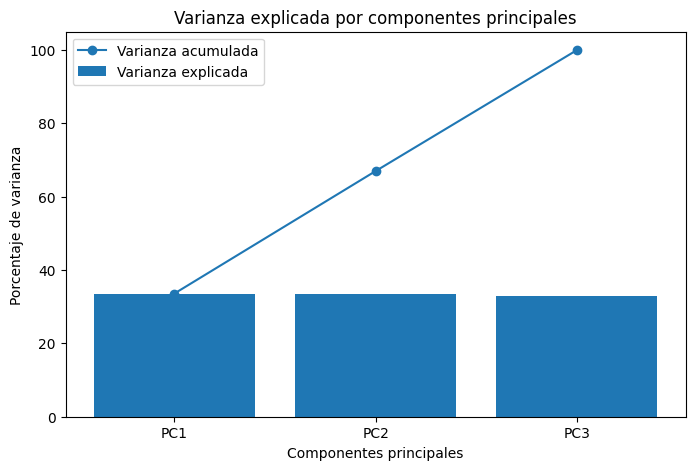

In [13]:
# Visualización de varianza explicada y acumulada

plt.figure(figsize=(8, 5))

plt.bar(
    varianza_pca["Componente"],
    varianza_pca["Varianza explicada (%)"],
    label="Varianza explicada"
)

plt.plot(
    varianza_pca["Componente"],
    varianza_pca["Varianza acumulada (%)"],
    marker="o",
    label="Varianza acumulada"
)

plt.title("Varianza explicada por componentes principales")
plt.xlabel("Componentes principales")
plt.ylabel("Porcentaje de varianza")
plt.legend()
plt.show()

### Gráfico de varianza explicada

El gráfico permite observar cuánto aporta cada componente principal a la explicación de la variabilidad total.

Las barras muestran la varianza explicada por cada componente individual, mientras que la línea muestra la varianza acumulada.

Este análisis ayuda a decidir si se puede reducir la cantidad de dimensiones manteniendo una parte importante de la información original.

In [14]:
# Creamos un DataFrame con las dos primeras componentes principales

pca_df = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"]
)

# Agregamos el plan de suscripción para usarlo como color en el gráfico
pca_df["subscription_plan"] = df["subscription_plan"].values

pca_df.head()

,PC1,PC2,subscription_plan
0,0.485207,-0.056312,Estándar
1,1.245979,-0.088000,Estándar
2,-1.140606,-0.201611,Básico
3,-0.385820,-0.638282,Básico
4,1.052604,-0.501600,Básico


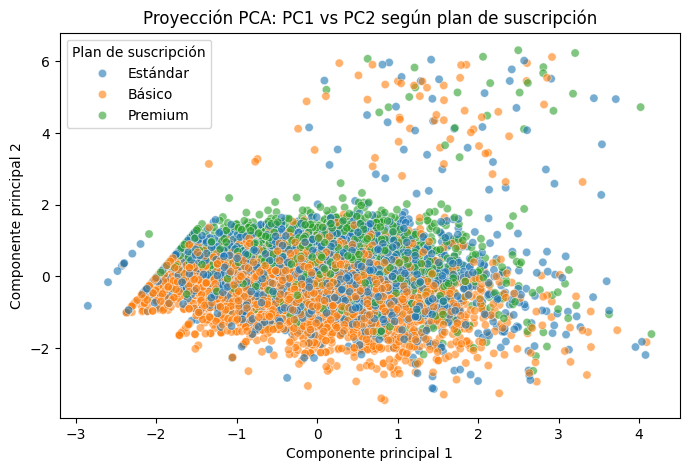

In [15]:
# Visualización de los usuarios proyectados en las dos primeras componentes principales

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="subscription_plan",
    alpha=0.6
)

plt.title("Proyección PCA: PC1 vs PC2 según plan de suscripción")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(title="Plan de suscripción")
plt.show()

### Proyección PCA: PC1 vs PC2 según plan de suscripción

El gráfico muestra a los usuarios proyectados sobre las dos primeras componentes principales.

Se observa que los colores correspondientes a los planes Básico, Estándar y Premium aparecen bastante mezclados. Esto indica que, con las variables numéricas utilizadas en PCA (`age`, `monthly_watch_time_mins` y `customer_support_tickets`), no se forma una separación clara entre los usuarios según el plan de suscripción.

También se observan algunos puntos alejados en la parte superior del gráfico, que podrían corresponder a usuarios con comportamientos más extremos, especialmente en relación con el tiempo mensual de visualización.

En este caso, PCA permite reducir y visualizar la información numérica, pero no muestra una segmentación fuerte de los usuarios por plan.

In [16]:
# Calculamos los loadings para interpretar las componentes principales

loadings = pd.DataFrame(
    pca.components_.T,
    index=variables_pca,
    columns=[f"PC{i+1}" for i in range(len(variables_pca))]
)

loadings.round(3)

,PC1,PC2,PC3
age,0.748,0.102,0.656
monthly_watch_time_mins,0.311,0.819,-0.482
customer_support_tickets,0.586,-0.565,-0.581


### Interpretación de las componentes principales

A partir de los loadings, se observa que la primera componente principal (PC1) está influenciada principalmente por `age` y `customer_support_tickets`. Esto sugiere que PC1 resume una dimensión relacionada con la edad del usuario y su nivel de contacto con soporte.

La segunda componente principal (PC2) está influenciada principalmente por `monthly_watch_time_mins`, por lo que representa con mayor fuerza las diferencias en el tiempo mensual de visualización.

Esta interpretación permite entender qué variables originales tienen mayor peso dentro de cada componente principal.

## Conclusiones del análisis PCA

En este notebook se aplicó PCA sobre las variables numéricas del dataset limpio: `age`, `monthly_watch_time_mins` y `customer_support_tickets`.

Antes de aplicar PCA, las variables fueron escaladas con `StandardScaler`, ya que tienen rangos diferentes. Esto evita que una variable domine el análisis únicamente por tener valores numéricos más grandes.

A partir de la varianza explicada, se observa que las tres componentes principales explican porcentajes muy similares de la variabilidad total. PC1 y PC2 juntas conservan aproximadamente el 67% de la información, por lo que la reducción a dos dimensiones resulta útil para visualizar, pero no conserva la totalidad de la variabilidad del dataset.

La proyección en PC1 y PC2 permitió visualizar a los usuarios en un espacio reducido. Sin embargo, los colores correspondientes a los planes de suscripción aparecen bastante mezclados, por lo que no se observa una separación clara entre Básico, Estándar y Premium usando únicamente estas variables numéricas.

El análisis de loadings mostró que PC1 está más influenciada por `age` y `customer_support_tickets`, mientras que PC2 está más relacionada con `monthly_watch_time_mins`.

En conclusión, PCA permitió resumir y visualizar la información numérica del dataset, pero en este caso la varianza se encuentra distribuida de manera pareja entre las tres componentes. Por eso, reducir a dos componentes es útil para graficar, aunque no representa una reducción fuerte sin pérdida de información.